# Part 1: PCA

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Step 1: Load Csv File and Drop Unused Columns

- Read csv file
- Drop columns for which the values are constant (provide no more info)

In [25]:
# read csv file
df = pd.read_csv("data/BitCoin_Mining.csv")
print(df.describe())

# drop columns that are not used
df = df.drop(columns=["timestamp", "mem_total", "latency_ms"])
df = df.dropna()

           mem_used  mem_total   power_watts      gpu_util   temperature  \
count  24957.000000    24957.0  24957.000000  24957.000000  24957.000000   
mean       3.960139        4.0     30.493423     99.013704     56.431262   
std        0.192408        0.0      8.577073      9.703038      3.039341   
min        0.160000        4.0      2.830000      0.000000     50.000000   
25%        3.970000        4.0     26.940000    100.000000     54.000000   
50%        3.970000        4.0     27.120000    100.000000     56.000000   
75%        3.970000        4.0     27.470000    100.000000     58.000000   
max        3.970000        4.0     50.430000    100.000000     67.000000   

          fan_speed    core_clock  memory_clock    pcie_rx_MB   pcie_tx_MB  \
count  24957.000000  24957.000000  24957.000000  24957.000000  24957.00000   
mean   32765.687062   1772.709460   5954.746965      1.657050      0.02929   
std      207.415158    132.401724    500.983538      0.759343      0.16886   
min

## Step 2: Look at Correlation Matrix

- Calculate correlation coefficient between variables
- Create a heatmap to observe relationships

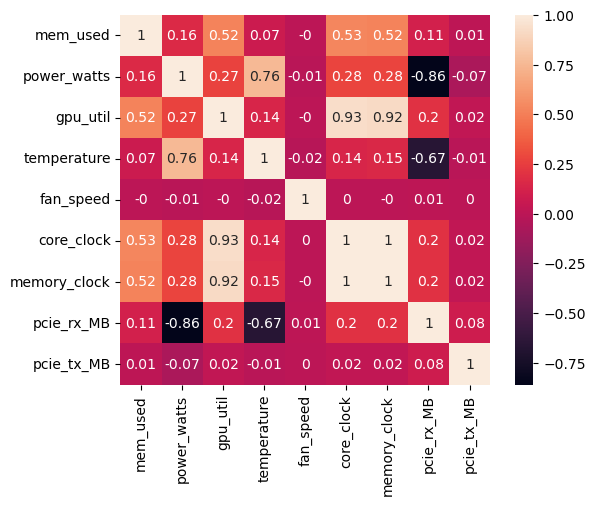

In [26]:
co_mtx = round(df.corr(numeric_only=True), 2)
sns.heatmap(co_mtx, annot=True, square=True)
plt.show()

## Step 3: Scaling Data for PCA

Scale each column based on: 

$$x_i = \frac{x_i - \mu}{\sigma}$$

- $x_i$ is the i'th value in column x
- $\mu$ is the **mean** of the column (x)
- $\sigma$ is the **standard deviation** of the column (x)


In [27]:
# convert to df to numpy array 
features = df.drop(columns=['temperature'])
X_data = features.values.astype(float)

# get mean of each column
mean_cols = X_data.mean(axis=0)

# get std
std_cols = X_data.std(axis=0)

scaled_X_data = (X_data - mean_cols)/ std_cols

# check mean and std are 0 and 1
scaled_df = pd.DataFrame(scaled_X_data, columns=features.columns)
scaled_df.describe().round(3)

,mem_used,power_watts,gpu_util,fan_speed,core_clock,memory_clock,pcie_rx_MB,pcie_tx_MB
count,24957.000,24957.000,24957.000,24957.000,24957.000,24957.000,24957.000,24957.000
mean,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-19.751,-3.225,-10.205,-157.975,-11.123,-11.078,-2.182,-0.173
25%,0.051,-0.414,0.102,0.006,0.093,0.090,0.452,-0.173
50%,0.051,-0.393,0.102,0.006,0.093,0.090,0.452,-0.173
75%,0.051,-0.353,0.102,0.006,0.093,0.090,0.452,-0.173
max,0.051,2.324,0.102,0.006,0.093,0.090,1.769,11.671


## Step 3: Perform PCA

- Compute SVD 
- Compute explained variance for each principal component, can be done using:

$$ variance_i = \frac{\sigma_i^2}{n-1}$$
$$ explained\space{} variance = \frac{variance_i}{total\space{}variance}$$

source: https://molgorithm.medium.com/how-to-calculate-explained-variance-ratio-in-pca-using-svd-ab531b434e6

- where $\sigma_i$ is the singular value
- where n = number of rows in the X matrix

- Create cumulative variance plot to determine number of principle components
- Retain X principal components and use $X = TP^T$ to compute new matrix

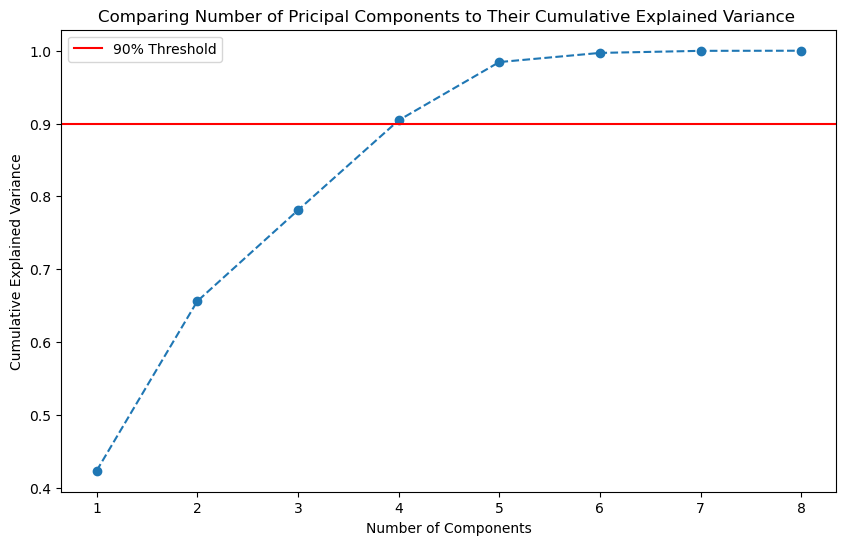

In [28]:
# perform SVD (Economy)

U , Sigma, Vt = np.linalg.svd(scaled_X_data, full_matrices=False)

# compute explained variance
variances = (Sigma**2) / (scaled_X_data.shape[0] - 1)
explained_variances = variances/variances.sum()

# compute cumulative variance
cumulative_variance = np.cumsum(explained_variances)

# make a plot to determine number of principal components based on threshold
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.9, color='r', linestyle='-', label='90% Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Comparing Number of Pricipal Components to Their Cumulative Explained Variance ')
plt.legend()
plt.show()

Based on the plot above we need at least 4 principal components to meet desired threshold.

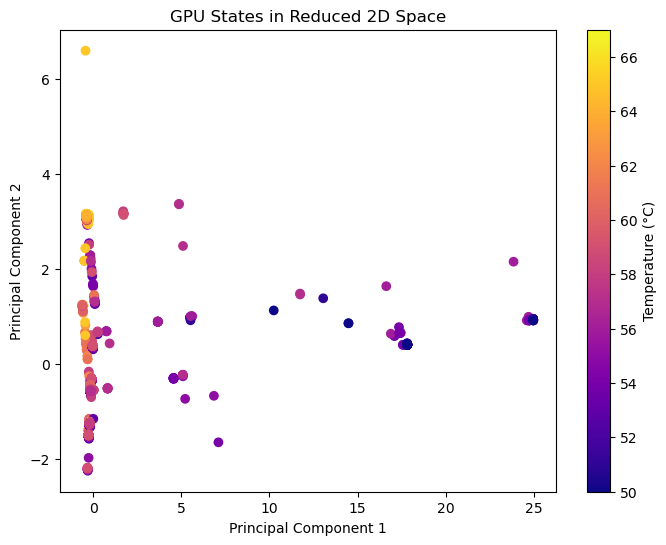

In [29]:
# num of principal components 
k = 4
U_hat = U[:, :k]
Sigma_hat = Sigma[:k]
V_hat = Vt[:k, :].T

# calculate T scores
T = U_hat * Sigma_hat
pca_result = T

# plot the first two principal components along with temperaure
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df['temperature'], cmap='plasma')
plt.colorbar(label='Temperature (°C)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('GPU States in Reduced 2D Space')
plt.show()

# Part 2 : Regression

In [30]:
from sklearn.preprocessing import PolynomialFeatures

## Step 1: Create Training and Test Data 
- 80/20 split for training and test
- shuffle data to get random samples in each training/test dataset


In [31]:
X = X_data
# convert to numpy array
y = df['temperature'].values.astype(float)

# get number of vals in test/test
num_rows = X.shape[0]
num_vals_train = int(0.8 * num_rows)
num_vals_test = num_rows - num_vals_train

# random seed to reproduce
np.random.seed(20)

# get indices for each
shuffled_rows = np.random.permutation(num_rows)
train_idxs = shuffled_rows[:num_vals_train]
test_idxs = shuffled_rows[num_vals_train:]

X_train_raw = X[train_idxs]
X_test_raw = X[test_idxs]
# adding the bias column of ones 
X_train = np.hstack([np.ones((X_train_raw.shape[0], 1)), X_train_raw])
X_test  = np.hstack([np.ones((X_test_raw.shape[0], 1)), X_test_raw])

y_train = y[train_idxs]
y_test = y[test_idxs]

print(f"Dataset Size: {X.shape[0]}")
print(f"Train Size: {X_train.shape[0]}")
print(f"Test Size: {X_test.shape[0]}")

Dataset Size: 24957
Train Size: 19965
Test Size: 4992


### Perfoming ridge and Ridge Regression using Principal components

As defined in lecture Ridge-Regression is: 

$$\mathbf{a}^* := [\Theta^T\Theta + \mu \mathbf{I}]^{-1}\Theta^T\mathbf{y} \quad \text{for some } \mu > 0$$

and Linear Regression using (ridge): 
$$\mathbf{a}^* := [\Theta^T\Theta]^{-1}\Theta^T\mathbf{y}$$

We can perform these and fit the model to see how good they perform on test data


In [32]:
# function to perfom ordinary least squares (OLS)
def ols(theta, y):
    theta_T_theta = np.matmul(theta.T,theta)
    theta_T_y = np.matmul(theta.T,y)
    a_star = np.linalg.solve(theta_T_theta, theta_T_y)
    return a_star

# function to perfom ridge regression
def ridge(theta, y, mu):
    theta_T_theta = np.matmul(theta.T,theta)
    theta_T_y = np.matmul(theta.T,y)
    a_star = np.linalg.solve(theta_T_theta + (mu * np.eye(theta_T_theta.shape[0])), theta_T_y)
    return a_star
    


### Training data and creating predictions to compare to test data 

#### OLS

<Figure size 1000x600 with 0 Axes>

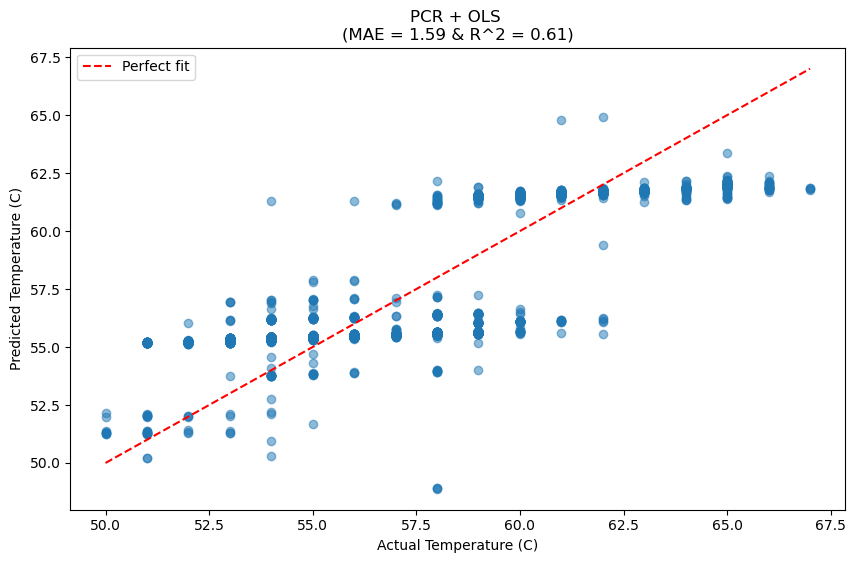

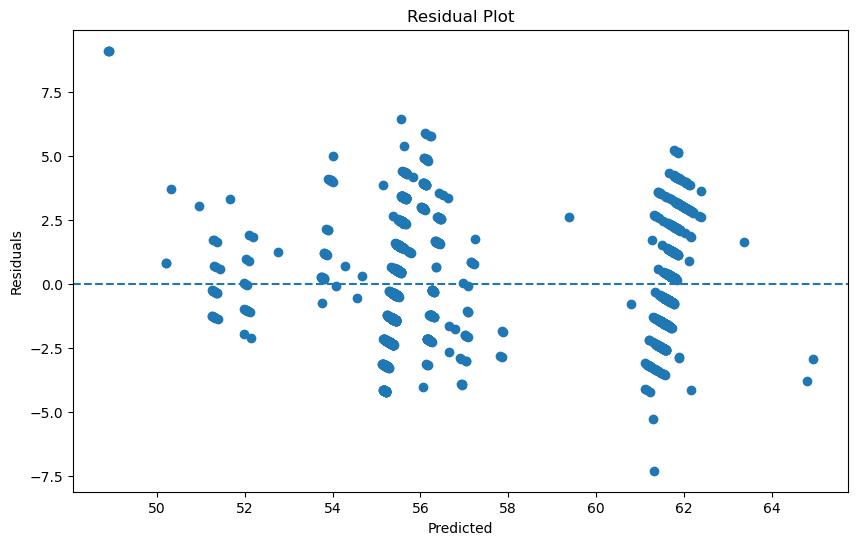

In [33]:

a_star_ols = ols(X_train, y_train)
y_pred_ols = np.matmul(X_test, a_star_ols)
# get MAE and R^2 value 
mae_ols = np.mean(np.abs(y_test - y_pred_ols))
r_squared_ols = 1 - np.sum((y_test - y_pred_ols)**2) / np.sum((y_test - y_test.mean())**2)

# create plot to show comparison of actual vs predicted for OLS model 
plt.figure(figsize=[10,6])
plt.figure(figsize=[10,6])
plt.scatter(y_test,y_pred_ols, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', label='Perfect fit')
plt.xlabel('Actual Temperature (C)')
plt.ylabel('Predicted Temperature (C)')
plt.title(f'PCR + OLS \n(MAE = {mae_ols:.2f} & R^2 = {r_squared_ols:.2f})')
plt.legend()

#residual plot
residuals = y_test - y_pred_ols
plt.figure(figsize=[10,6])
plt.scatter(y_pred_ols, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

The residual plot shows that the spread of the residuals change across the predictions (ie not constnat variance). This suggests that a linear model may not fully explain the relationship accurately

#### Ridge Regression

In [34]:

# perform some basic paramater tuning on penalty term mu
mu_values = [0.001, 0.05, 0.1, 1, 5, 10, 100, 1000]
res = []
for mu in mu_values:
    a_star_ridge = ridge(X_train, y_train, mu)
    y_pred_ridge  = np.matmul(X_test, a_star_ridge)
    # get MAE and R^2 value 
    mae_ridge = np.mean(np.abs(y_test - y_pred_ridge))
    r_squared_ridge = 1 - np.sum((y_test - y_pred_ridge)**2) / np.sum((y_test - y_test.mean())**2)
    res.append({"mu":mu, "mae":mae_ridge, "r2":r_squared_ridge})

# get mu corresponding to lowest MAE
best_mu = min(res, key=lambda x: x["mae"])["mu"]
print(best_mu)
print(res)

0.001
[{'mu': 0.001, 'mae': np.float64(1.5858387402001892), 'r2': np.float64(0.6072768461481985)}, {'mu': 0.05, 'mae': np.float64(1.5859075667368192), 'r2': np.float64(0.6071928878807976)}, {'mu': 0.1, 'mae': np.float64(1.5860042024735526), 'r2': np.float64(0.6071121583762773)}, {'mu': 1, 'mae': np.float64(1.586904304792245), 'r2': np.float64(0.6062241022957392)}, {'mu': 5, 'mae': np.float64(1.5878580685511763), 'r2': np.float64(0.6053338006045581)}, {'mu': 10, 'mae': np.float64(1.588339046444761), 'r2': np.float64(0.6050924014040826)}, {'mu': 100, 'mae': np.float64(1.5909550033161366), 'r2': np.float64(0.6042778632202894)}, {'mu': 1000, 'mae': np.float64(1.6042096113705087), 'r2': np.float64(0.5994611657342837)}]


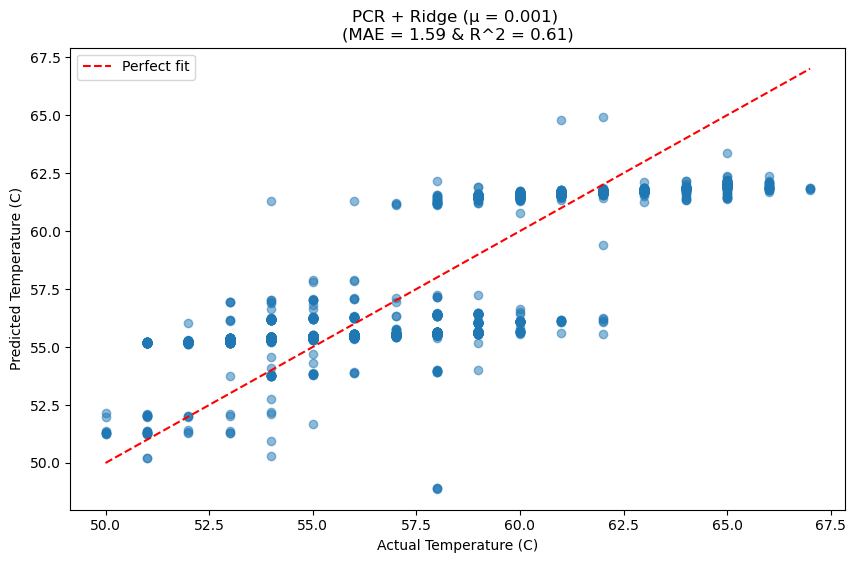

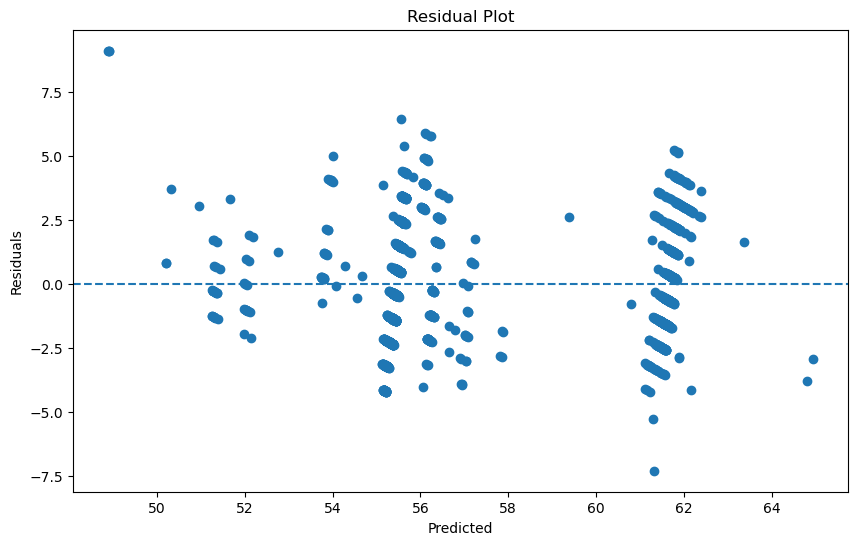

In [35]:
a_star_ridge = ridge(X_train, y_train, best_mu)
y_pred_ridge  = np.matmul(X_test, a_star_ridge)
mae_ridge = np.mean(np.abs(y_test - y_pred_ridge))
r_squared_ridge = 1 - np.sum((y_test - y_pred_ridge)**2) / np.sum((y_test - y_test.mean())**2)
# create plot to show comparison of actual vs predicted for OLS model 
plt.figure(figsize=[10,6])
plt.scatter(y_test,y_pred_ridge, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', label='Perfect fit')
plt.xlabel('Actual Temperature (C)')
plt.ylabel('Predicted Temperature (C)')
plt.title(f'PCR + Ridge (μ = {best_mu}) \n(MAE = {mae_ridge:.2f} & R^2 = {r_squared_ridge:.2f})')
plt.legend()

#residual plot
residuals = y_test - y_pred_ridge
plt.figure(figsize=[10,6])
plt.scatter(y_pred_ols, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

The ridge regression yields near identical results to the ols regression, so we can try using polynomial feature space to see if it yields better outcomes. We will use ridge because it did have a slightly better MAE.

In [36]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train_raw)
X_test_poly = poly.transform(X_test_raw)

# perform some basic paramater tuning on penalty term mu
mu_values = [0.001, 0.05, 0.1, 1, 5, 10, 100, 1000]
res_poly = []
for mu in mu_values:
    a_star_ridge_poly = ridge(X_train_poly, y_train, mu)
    y_pred_ridge  = np.matmul(X_test_poly, a_star_ridge_poly)
    # get MAE and R^2 value 
    mae_ridge_poly = np.mean(np.abs(y_test - y_pred_ridge))
    r_squared_ridge_poly = 1 - np.sum((y_test - y_pred_ridge)**2) / np.sum((y_test - y_test.mean())**2)
    res_poly.append({"mu":mu, "mae":mae_ridge_poly, "r2":r_squared_ridge_poly})

# get mu corresponding to lowest MAE
best_mu_poly = min(res_poly, key=lambda x: x["mae"])["mu"]
print(best_mu_poly)
print(res_poly)


1
[{'mu': 0.001, 'mae': np.float64(1.1816283816267086), 'r2': np.float64(0.6135789411946146)}, {'mu': 0.05, 'mae': np.float64(1.1794763025967405), 'r2': np.float64(0.657936458446463)}, {'mu': 0.1, 'mae': np.float64(1.1780612836114746), 'r2': np.float64(0.6818691801612806)}, {'mu': 1, 'mae': np.float64(1.1749566153941948), 'r2': np.float64(0.7177031445758177)}, {'mu': 5, 'mae': np.float64(1.178453179511963), 'r2': np.float64(0.7119615872727167)}, {'mu': 10, 'mae': np.float64(1.178775277705181), 'r2': np.float64(0.7114002139429818)}, {'mu': 100, 'mae': np.float64(1.1773736543943885), 'r2': np.float64(0.7160180979470352)}, {'mu': 1000, 'mae': np.float64(1.1779247549850034), 'r2': np.float64(0.7154914569151818)}]


#### Use best $\mu$ to perform ridge regression (Poly Features)

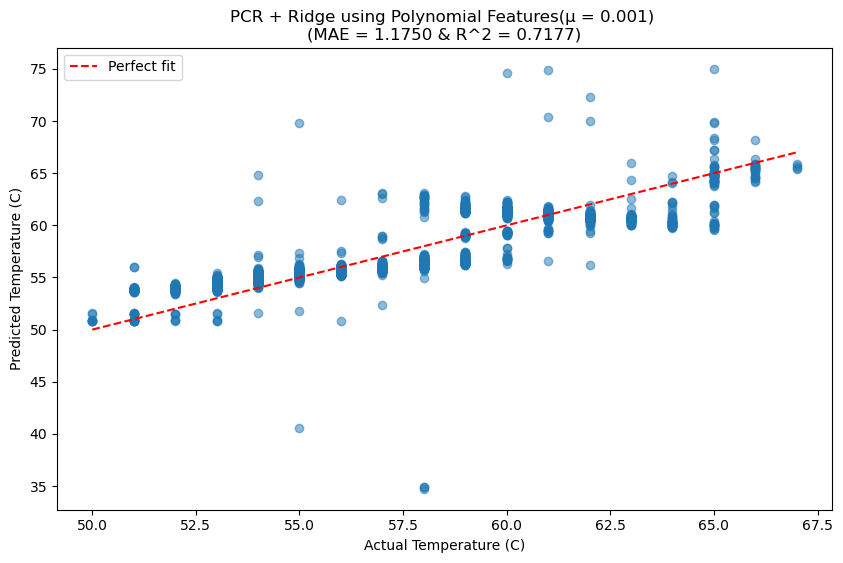

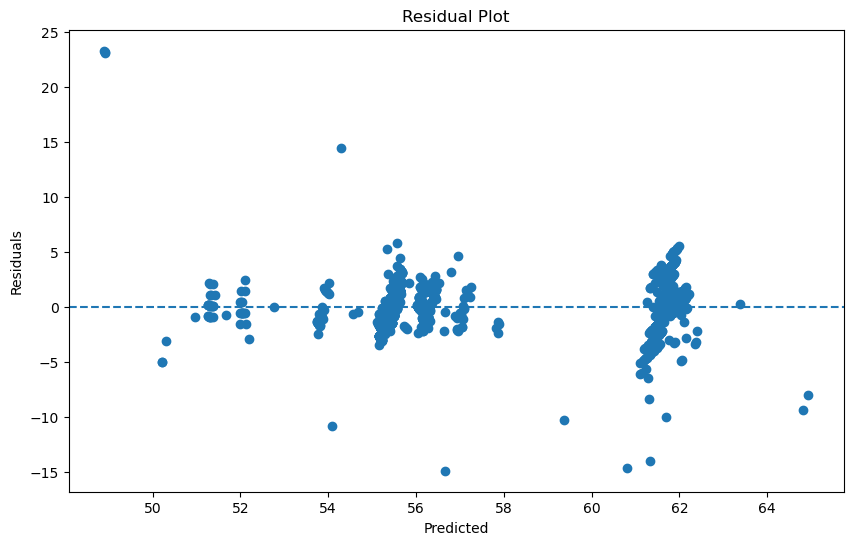

In [37]:
a_star_ridge_poly = ridge(X_train_poly, y_train, best_mu_poly)
y_pred_ridge_poly  = np.matmul(X_test_poly, a_star_ridge_poly)
mae_ridge_poly = np.mean(np.abs(y_test - y_pred_ridge_poly))
r_squared_ridge_poly = 1 - np.sum((y_test - y_pred_ridge_poly)**2) / np.sum((y_test - y_test.mean())**2)
# create plot to show comparison of actual vs predicted for OLS model 
plt.figure(figsize=[10,6])
plt.scatter(y_test,y_pred_ridge_poly, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', label='Perfect fit')
plt.xlabel('Actual Temperature (C)')
plt.ylabel('Predicted Temperature (C)')
plt.title(f'PCR + Ridge using Polynomial Features(μ = {best_mu}) \n(MAE = {mae_ridge_poly:.4f} & R^2 = {r_squared_ridge_poly:.4f})')
plt.legend()

#residual plot
residuals = y_test - y_pred_ridge_poly
plt.figure(figsize=[10,6])
plt.scatter(y_pred_ols, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()